# Matched IsoNCA LPPN decoder experiments V3 (GPU)

GPU notebook for the controlled study in `docs/isonca_isotropic_lppn_experiments_2026-07-23.md`. It works on any compatible CUDA GPU host.

The `lap_gradnorm` IsoNCA, lizard target, invariant loss, living-mask gating, alpha supervision, pool schedule, and optimizer are held fixed. One selected decoder is trained per run:

- `cartesian_coords`: the original Cartesian sub-cell-coordinate LPPN quality baseline.
- `isotropic_neighbors`: the proposed four-cell, shared-message, permutation-invariant decoder without geometric inputs.
- `isotropic_neighbors_radial`: the same decoder with radial distance as a controlled extension.
- `interpolated_only`: the completed no-coordinate baseline, included for smoke tests or a fresh replication.

Use a GPU runtime. Checkpoints are written every 5,000 steps and resume automatically. They are stored below the configurable checkpoint root. The decoder-only test uses arbitrary non-symmetric fields; the end-to-end test uses paired stochastic update masks so it does not collapse to the deterministic radial-disk diagnostic from the earlier notebook.

## August 18 feedback implemented here

- Increase transparent padding from 32 to 128 pixels per side so the lizard remains inside the canvas at arbitrary orientations.
- Use dense full-circle FFT-loss sampling. `InvariantImageLoss` uses the suggested `torch.arange(0, w * torch.pi + 1) / (w / 2)` angles; the build cell below validates it.
- Every 10,000 training steps, replace the complete pool with fresh seeds.
- Reduce both decoder hidden widths from 96 to 64.

## V3 stabilization change

V2 reproduced the suggested joint pool/optimizer reset, but its loss spikes aligned with the restarted cyclic learning-rate peaks. V3 therefore flushes only the pool: Adam moments and the scheduler remain continuous. It also lowers the peak learning rate, saves the best smoothed-loss state, and retains numbered checkpoints. The separate `v3` tag prevents V2 checkpoints from being resumed into this run.

In [1]:
#@title Clone/update repository and prepare GPU environment
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

REPO_URL = 'https://github.com/IvanLudvig/Cells2Pixels.git'
BRANCH = 'isotropic'
REPO_DIR = 'Cells2Pixels'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

WORKSPACE_ROOT = Path.cwd()

if Path('train.py').exists():
    repo_path = Path.cwd()
elif (WORKSPACE_ROOT / REPO_DIR / 'train.py').exists():
    repo_path = WORKSPACE_ROOT / REPO_DIR
    subprocess.run(['git', '-C', str(repo_path), 'pull', '--ff-only'], check=True)
else:
    repo_path = WORKSPACE_ROOT / REPO_DIR
    subprocess.run(
        ['git', 'clone', '--branch', BRANCH, REPO_URL, str(repo_path)], check=True
    )
os.chdir(repo_path)

# Use a PyTorch GPU environment with compatible CUDA PyTorch and torchvision.
# Install only the lightweight packages needed by this 2D notebook.
package_by_module = {
    'numpy': 'numpy', 'matplotlib': 'matplotlib', 'requests': 'requests',
    'PIL': 'Pillow', 'yaml': 'PyYAML', 'moviepy': 'moviepy==1.0.3', 'tqdm': 'tqdm',
}
missing_packages = [
    package for module, package in package_by_module.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', *missing_packages], check=True)
try:
    import torch
    import torchvision
except Exception as exc:
    raise RuntimeError(
        'Start this notebook from a compatible PyTorch GPU environment with torch/torchvision installed.'
    ) from exc

if not Path('models/isotropic_lppn.py').exists():
    raise FileNotFoundError(
        'models/isotropic_lppn.py is missing. Commit and push the prepared experiment files before running the notebook.'
    )
print('Environment:', 'Colab' if IN_COLAB else 'GPU host')
print('cwd:', Path.cwd())
print('branch:', subprocess.run(['git', 'branch', '--show-current'], capture_output=True, text=True).stdout.strip())

Cloning into '/workspace/Cells2Pixels'...


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 40.8 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 83.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 93.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 110.5 MB/s  0:00:00
  Created wheel for moviepy: filename=moviepy-1.0.3-py3-none-any.whl size=110796 sha256=72b50b37c295c2584a66400f2de2733fea92435798bb1fd54a49dc9e0c140312
  Stored in directory: /root/.cache/pip/wheels/df/ba/4b/0917fc0c8833c8ba7016565fc975b74c67bc8610806e930272
Successfully built moviepy
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [moviepy

Environment: GPU host
cwd: /workspace/Cells2Pixels
branch: isotropic


In [2]:
#@title Imports and device setup
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import random
import requests
import torch
import torch.nn.functional as F
from IPython.display import clear_output, display
from PIL import Image

from losses.invariant_image_loss import InvariantImageLoss
from models.isonca import GradNormIsoGrowingNCA
from models.isotropic_lppn import IsotropicNeighborhoodLPPN
from models.siren import Siren
from training.common import make_grad_scaler, normalize_model_grads, optimizer_scheduler_step, set_seed
from utils.misc import autocast_context
from utils.render import Renderer2D

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Torch:', torch.__version__)
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: training on CPU will be very slow; select a GPU runtime.')

Torch: 2.11.0+cu128
Device: cuda:0


/workspace/Cells2Pixels/utils/icosphere.py:181: SyntaxWarning: invalid escape sequence '\ '
  indexing given by reading order             / \ / \
/workspace/Cells2Pixels/utils/icosphere.py:208: SyntaxWarning: invalid escape sequence '\ '
  first corners vertices, then on-edges       / \ / \
/workspace/Cells2Pixels/utils/icosphere.py:236: SyntaxWarning: invalid escape sequence '\ '
  given coordinates of the on-edge               / \ / \


GPU: NVIDIA GeForce RTX 5060 Ti


Target: data/morphology_png/lizard.png | size: (512, 512)


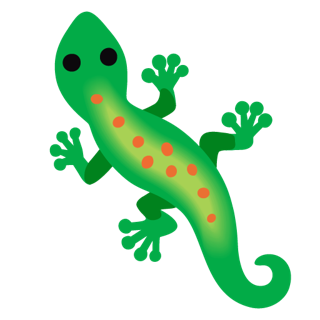

In [3]:
#@title Prepare the Noto lizard target
TARGET_IMAGE_PATH = Path('data/morphology_png/lizard.png')
LIZARD_URL = 'https://github.com/googlefonts/noto-emoji/blob/main/png/512/emoji_u1f98e.png?raw=true'

def ensure_lizard_target(path):
    path = Path(path)
    if path.exists():
        return path
    path.parent.mkdir(parents=True, exist_ok=True)
    response = requests.get(
        LIZARD_URL,
        headers={'User-Agent': 'Cells2Pixels IsoNCA notebook'},
        timeout=60,
    )
    response.raise_for_status()
    Image.open(BytesIO(response.content)).convert('RGBA').save(path)
    return path

ensure_lizard_target(TARGET_IMAGE_PATH)
target_preview = Image.open(TARGET_IMAGE_PATH).convert('RGBA')
print('Target:', TARGET_IMAGE_PATH, '| size:', target_preview.size)
display(target_preview.resize((320, 320)))

In [4]:
#@title Experiment settings
VARIANT_TO_RUN = 'isotropic_neighbors'  #@param ['cartesian_coords', 'isotropic_neighbors', 'isotropic_neighbors_radial', 'interpolated_only']
TRAIN_STEPS = 50000  #@param {type: 'integer'}
BATCH_SIZE = 2  #@param {type: 'integer'}
USE_GOOGLE_DRIVE = True  #@param {type: 'boolean'}
RESUME_FROM_CHECKPOINT = True  #@param {type: 'boolean'}

SEED = 43
PRECISION = torch.float32  # FFT loss + long unroll overflowed under AMP/fp16 on a T4.
IMAGE_SIZE = (512, 512)
# A 512 px square needs about 106 px/side to contain its footprint at 45 degrees.
# Use 128 px to leave an additional transparent safety margin.
PADDING = (128, 128)
SCALE_FACTOR = 8
CHANNELS = 16
FC_DIM = 128
UPDATE_PROB = 0.5

SIREN_HIDDEN = 64
SIREN_LAYERS = 2
SIREN_FREQUENCIES = 1
MESSAGE_FEATURES = 48
NEIGHBOR_HIDDEN = 64
PHI_HIDDEN_LAYERS = 1
RHO_HIDDEN_LAYERS = 1

POOL_SIZE = 256
STEP_RANGE = (64, 96)
EARLY_SEED_STEPS = 4000
POOL_FLUSH_INTERVAL = 10000
SUMMARY_INTERVAL = 500
CHECKPOINT_INTERVAL = 5000
BEST_LOSS_WINDOW = 500
DAMAGE_ENABLED = False
SUPERVISE_NCA_ALPHA = True

LR = 3e-4
LR_BASE = 1e-5
LR_CYCLE_STEP_UP = 2000
OVERFLOW_WEIGHT = 10.0
DIFF_WEIGHT = 10.0
EVAL_STEPS = 96
EXPERIMENT_TAG = 'v3'

if USE_GOOGLE_DRIVE and IN_COLAB:
    try:
        from google.colab import drive
    except ImportError:
        CHECKPOINT_ROOT = Path('notebook_runs')
        print('Google Drive unavailable; using local notebook_runs/.')
    else:
        drive.mount('/content/drive')
        CHECKPOINT_ROOT = Path('/content/drive/MyDrive/Cells2Pixels/notebook_runs')
else:
    CHECKPOINT_ROOT = Path('notebook_runs')
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
set_seed(SEED)
print('Selected variant:', VARIANT_TO_RUN)
print('Checkpoint root:', CHECKPOINT_ROOT / EXPERIMENT_TAG)

Selected variant: isotropic_neighbors
Checkpoint root: notebook_runs/v3


In [5]:
#@title Build and render helpers
def make_loss():
    return InvariantImageLoss(
        target_path=str(TARGET_IMAGE_PATH),
        image_size=IMAGE_SIZE,
        padding=PADDING,
        premultiply_alpha=True,
        aux_type='binary',
        mirror=True,
        sharpen=True,
        l2_weight=1.0,
        include_nca_alpha=SUPERVISE_NCA_ALPHA,
        device=device,
    )

def make_seed(model, n, h, w):
    return model.seed(n, h, w).to(device=device, dtype=PRECISION)

def make_decoder(name, out_features, scale_factor=SCALE_FACTOR):
    if name in {'cartesian_coords', 'interpolated_only'}:
        return Siren(
            in_features=CHANNELS,
            coord_dim=2,
            out_features=out_features,
            hidden_features=SIREN_HIDDEN,
            hidden_layers=SIREN_LAYERS,
            outermost_linear=True,
            fx='linear',
            activation='sin',
            num_frequencies=SIREN_FREQUENCIES,
            first_omega_0=10.0,
            hidden_omega_0=10.0,
            disable=False,
            disable_coords=(name == 'interpolated_only'),
        ).to(device)
    if name in {'isotropic_neighbors', 'isotropic_neighbors_radial'}:
        return IsotropicNeighborhoodLPPN(
            in_features=CHANNELS,
            out_features=out_features,
            scale_factor=scale_factor,
            message_features=MESSAGE_FEATURES,
            hidden_features=NEIGHBOR_HIDDEN,
            phi_hidden_layers=PHI_HIDDEN_LAYERS,
            rho_hidden_layers=RHO_HIDDEN_LAYERS,
            radial_distance=(name == 'isotropic_neighbors_radial'),
            aggregation='mean',
        ).to(device)
    raise ValueError(f'Unknown decoder variant: {name}')

def make_renderer(scale_factor=SCALE_FACTOR):
    return Renderer2D(
        scale_factor=scale_factor,
        padding='circular',
        fs_shader='vanilla',
        precision=PRECISION,
    )

def decode_raw(name, decoder, renderer, state, scale_factor=None, neighbor_permutation=None):
    if name.startswith('isotropic_neighbors'):
        return decoder(
            state.to(torch.float32),
            scale_factor=scale_factor,
            neighbor_permutation=neighbor_permutation,
        ).to(torch.float32)
    if neighbor_permutation is not None:
        raise ValueError('neighbor_permutation applies only to neighborhood decoders')
    if scale_factor is not None and scale_factor != renderer.scale_factor:
        renderer = make_renderer(scale_factor)
    return renderer.render(
        state.to(torch.float32).permute(0, 2, 3, 1),
        decoder,
        None,
        fs_shader='vanilla',
        hard_clamp=False,
    ).to(torch.float32)

def render_channels(name, model, decoder, renderer, state, scale_factor=None):
    image = decode_raw(name, decoder, renderer, state, scale_factor=scale_factor)
    x_up = F.interpolate(
        state.to(torch.float32),
        size=image.shape[1:3],
        mode='bilinear',
        align_corners=False,
    )
    living_mask = model.get_living_mask(x_up).to(image.dtype).permute(0, 2, 3, 1)
    return image * living_mask

def build_variant(name):
    loss_fn = make_loss()
    # Guard the dense full-circle sampling requested by Ehsan. The shared
    # loss builds exactly: arange(0, w*pi + 1) / (w/2).
    w = loss_fn.target_image.shape[-1]
    expected_angles = torch.arange(
        0, w * torch.pi + 1, device=device, dtype=loss_fn.target_image.dtype
    ) / (w / 2)
    expected_radii = torch.linspace(
        0.5 / w, 1, w // 2, device=device, dtype=loss_fn.target_image.dtype
    )[:, None]
    expected_polar_xy = torch.stack(
        [expected_radii * expected_angles.cos(), expected_radii * expected_angles.sin()], dim=-1
    )[None]
    if not torch.allclose(loss_fn.polar_xy, expected_polar_xy):
        raise ValueError('InvariantImageLoss is not using the requested dense angle sampling')
    model = GradNormIsoGrowingNCA(
        channels=CHANNELS,
        fc_dim=FC_DIM,
        update_prob=UPDATE_PROB,
        device=device,
        precision=PRECISION,
    ).to(device)
    decoder = make_decoder(name, loss_fn.channel_n)
    renderer = make_renderer()
    grid_size = (
        loss_fn.grid_size[0] // SCALE_FACTOR,
        loss_fn.grid_size[1] // SCALE_FACTOR,
    )
    parameter_n = sum(p.numel() for p in decoder.parameters())
    print(
        name, '| render:', loss_fn.grid_size, '| NCA:', grid_size,
        '| loss angles:', len(expected_angles), '| decoder params:', f'{parameter_n:,}'
    )
    return model, decoder, loss_fn, renderer, grid_size

def composite_rgba(image):
    image = np.asarray(image)
    rgb = np.clip(image[..., :3], 0.0, 1.0)
    alpha = np.clip(image[..., 3:4], 0.0, 1.0)
    return rgb + (1.0 - alpha)

def rotate_nchw(image, angle_deg):
    angle = torch.as_tensor(angle_deg * torch.pi / 180.0, device=image.device, dtype=image.dtype)
    c, s = torch.cos(angle), torch.sin(angle)
    theta = torch.zeros(image.shape[0], 2, 3, device=image.device, dtype=image.dtype)
    theta[:, 0, 0] = c
    theta[:, 0, 1] = -s
    theta[:, 1, 0] = s
    theta[:, 1, 1] = c
    grid = F.affine_grid(theta, image.shape, align_corners=False)
    return F.grid_sample(image, grid, mode='bilinear', padding_mode='zeros', align_corners=False)

@torch.no_grad()
def align_render_to_target(loss_fn, rendered, nca_alpha, sample_index=0):
    """Apply the invariant loss's selected orientation for visualization only."""
    generated = rendered[sample_index:sample_index + 1, :loss_fn.channel_n]
    alpha = nca_alpha[sample_index:sample_index + 1].to(generated)
    loss_input = torch.cat([generated, alpha], dim=1) if loss_fn.include_nca_alpha else generated
    alignment_losses = loss_fn.calc_losses(loss_input)
    phase_n = loss_fn.polar_target.shape[-1]
    best_index = int(alignment_losses[0].argmin().item())
    mirrored = loss_fn.mirror and best_index >= phase_n
    phase_index = best_index % phase_n
    phase_angle = 360.0 * phase_index / phase_n

    # The FFT correlation fixes the phase and reflection branch. Try the
    # equivalent spatial-transform conventions and retain the one that
    # maps the generated supervised channels to the canonical target.
    candidates = []
    for signed_angle in (phase_angle, -phase_angle):
        if mirrored:
            candidates.extend([
                (f'rot{signed_angle:+.2f}+flip_x', torch.flip(rotate_nchw(loss_input, signed_angle), dims=(-1,))),
                (f'rot{signed_angle:+.2f}+flip_y', torch.flip(rotate_nchw(loss_input, signed_angle), dims=(-2,))),
                (f'flip_x+rot{signed_angle:+.2f}', rotate_nchw(torch.flip(loss_input, dims=(-1,)), signed_angle)),
                (f'flip_y+rot{signed_angle:+.2f}', rotate_nchw(torch.flip(loss_input, dims=(-2,)), signed_angle)),
            ])
        else:
            candidates.append((f'rot{signed_angle:+.2f}', rotate_nchw(loss_input, signed_angle)))

    target = loss_fn.target_image
    if loss_fn.include_nca_alpha:
        target = torch.cat([target, target[:, 3:4]], dim=1)
    scored = [((candidate[:, :loss_fn.loss_channel_n] - target).square().mean(), label, candidate) for label, candidate in candidates]
    score, label, aligned = min(scored, key=lambda item: item[0].item())
    info = {
        'loss_branch': 'mirror' if mirrored else 'rotation',
        'phase_deg': phase_angle,
        'applied': label,
        'spatial_mse': float(score),
    }
    return aligned[:, :loss_fn.channel_n], info

def total_grad_norm(module):
    norms = [p.grad.detach().float().norm() for p in module.parameters() if p.grad is not None]
    return torch.linalg.vector_norm(torch.stack(norms)) if norms else torch.zeros((), device=device)

In [6]:
#@title Checkpoint helpers
DIRECTORY_NAMES = {
    'interpolated_only': 'isonca_lizard_lppn_no_coords',
    'cartesian_coords': 'isonca_lizard_lppn_coords',
    'isotropic_neighbors': 'isonca_lizard_lppn_isotropic_neighbors',
    'isotropic_neighbors_radial': 'isonca_lizard_lppn_isotropic_neighbors_radial',
}

def variant_output_dir(name, create=True):
    path = CHECKPOINT_ROOT / EXPERIMENT_TAG / DIRECTORY_NAMES[name]
    if create:
        path.mkdir(parents=True, exist_ok=True)
    return path

def make_optimizer(model, decoder):
    return torch.optim.Adam(list(model.parameters()) + list(decoder.parameters()), lr=LR_BASE)

def make_scheduler(optimizer):
    return torch.optim.lr_scheduler.CyclicLR(
        optimizer,
        base_lr=LR_BASE,
        max_lr=LR,
        step_size_up=LR_CYCLE_STEP_UP,
        mode='triangular2',
        cycle_momentum=False,
    )

def save_training_checkpoint(
        name, step, model, decoder, optimizer, scheduler, scaler, pool, history,
        filename='latest.pt',
):
    path = variant_output_dir(name) / filename
    temporary_path = path.with_suffix('.tmp')
    checkpoint = {
        'version': 3,
        'variant': name,
        'step': step,
        'model': model.state_dict(),
        'decoder': decoder.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(),
        'pool': pool.detach().cpu(),
        'history': history,
        'torch_rng_state': torch.get_rng_state(),
        'cuda_rng_state_all': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        'numpy_rng_state': np.random.get_state(),
        'python_rng_state': random.getstate(),
        'grid_size': tuple(pool.shape[-2:]),
        'pool_size': len(pool),
    }
    torch.save(checkpoint, temporary_path)
    os.replace(temporary_path, path)
    print(f'checkpoint saved: {path} (step {step})')

def restore_training_checkpoint(name, model, decoder, optimizer, scheduler, scaler, pool):
    path = variant_output_dir(name) / 'latest.pt'
    if not RESUME_FROM_CHECKPOINT or not path.exists():
        return 0, pool, []
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    checkpoint_variant = checkpoint.get('variant')
    accepted_names = {name}
    if name == 'interpolated_only':
        accepted_names.add('no_coords')
    if name == 'cartesian_coords':
        accepted_names.add('coords')
    if checkpoint_variant not in accepted_names:
        raise ValueError(f'Checkpoint variant mismatch: {checkpoint_variant} not in {accepted_names}')
    restored_pool = checkpoint['pool'].to(device=device, dtype=PRECISION)
    if restored_pool.shape != pool.shape:
        raise ValueError(f'Checkpoint pool {tuple(restored_pool.shape)} != expected {tuple(pool.shape)}')
    model.load_state_dict(checkpoint['model'])
    decoder.load_state_dict(checkpoint.get('decoder', checkpoint.get('siren')))
    optimizer.load_state_dict(checkpoint['optimizer'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    scaler.load_state_dict(checkpoint.get('scaler', {}))
    torch.set_rng_state(checkpoint['torch_rng_state'].cpu())
    if torch.cuda.is_available() and checkpoint.get('cuda_rng_state_all') is not None:
        torch.cuda.set_rng_state_all([state.cpu() for state in checkpoint['cuda_rng_state_all']])
    np.random.set_state(checkpoint['numpy_rng_state'])
    random.setstate(checkpoint['python_rng_state'])
    start_step = int(checkpoint['step']) + 1
    print(f'resumed: {path} (next step {start_step})')
    return start_step, restored_pool, checkpoint.get('history', [])

In [7]:
#@title Decoder-only D4 and permutation preflight (run before training)
def rel_l2(a, b):
    return (
        torch.linalg.vector_norm((a - b).reshape(a.shape[0], -1), dim=1)
        / (torch.linalg.vector_norm(b.reshape(b.shape[0], -1), dim=1) + 1e-8)
    )

D4_TRANSFORMS = [
    ('rot90', lambda x: torch.rot90(x, 1, (-2, -1)), lambda x: torch.rot90(x, 1, (-3, -2))),
    ('rot180', lambda x: torch.rot90(x, 2, (-2, -1)), lambda x: torch.rot90(x, 2, (-3, -2))),
    ('rot270', lambda x: torch.rot90(x, 3, (-2, -1)), lambda x: torch.rot90(x, 3, (-3, -2))),
    ('flip_x', lambda x: torch.flip(x, (-1,)), lambda x: torch.flip(x, (-2,))),
    ('flip_y', lambda x: torch.flip(x, (-2,)), lambda x: torch.flip(x, (-3,))),
]

@torch.no_grad()
def decoder_d4_rows(name, decoder, renderer, state):
    base = decode_raw(name, decoder, renderer, state)
    rows = []
    for label, transform_state, transform_image in D4_TRANSFORMS:
        actual = decode_raw(name, decoder, renderer, transform_state(state))
        expected = transform_image(base)
        rows.append((label, (actual - expected).abs().mean().item(), rel_l2(actual, expected).mean().item()))
    return rows

set_seed(SEED)
preflight_state = torch.randn(1, CHANNELS, 9, 9, device=device)
for preflight_name in ['interpolated_only', 'cartesian_coords', 'isotropic_neighbors', 'isotropic_neighbors_radial']:
    preflight_decoder = make_decoder(preflight_name, out_features=5, scale_factor=4)
    preflight_renderer = make_renderer(scale_factor=4)
    rows = decoder_d4_rows(preflight_name, preflight_decoder, preflight_renderer, preflight_state)
    max_error = max(row[2] for row in rows)
    print('\n' + preflight_name, '| params:', f'{sum(p.numel() for p in preflight_decoder.parameters()):,}')
    for label, mae, relative in rows:
        print(f'  {label:7s}  mae={mae:.3e}  rel_l2={relative:.3e}')
    if preflight_name == 'interpolated_only':
        assert max_error < 5e-5
    if preflight_name.startswith('isotropic_neighbors'):
        with torch.no_grad():
            base = decode_raw(preflight_name, preflight_decoder, preflight_renderer, preflight_state)
            permuted = decode_raw(
                preflight_name,
                preflight_decoder,
                preflight_renderer,
                preflight_state,
                neighbor_permutation=[2, 0, 3, 1],
            )
        permutation_error = rel_l2(permuted, base).mean().item()
        print(f'  neighbor permutation rel_l2={permutation_error:.3e}')
        assert max_error < 5e-5 and permutation_error < 5e-5
del preflight_state, preflight_decoder, base, permuted
if device.type == 'cuda':
    torch.cuda.empty_cache()


interpolated_only | params: 9,989
  rot90    mae=1.705e-08  rel_l2=1.907e-07
  rot180   mae=1.701e-08  rel_l2=1.893e-07
  rot270   mae=1.710e-08  rel_l2=1.918e-07
  flip_x   mae=1.585e-08  rel_l2=1.796e-07
  flip_y   mae=1.516e-08  rel_l2=1.730e-07

cartesian_coords | params: 9,989
  rot90    mae=3.554e-02  rel_l2=4.141e-01
  rot180   mae=3.849e-02  rel_l2=4.359e-01
  rot270   mae=3.542e-02  rel_l2=4.145e-01
  flip_x   mae=3.020e-02  rel_l2=3.435e-01
  flip_y   mae=2.649e-02  rel_l2=3.027e-01

isotropic_neighbors | params: 14,933
  rot90    mae=1.121e-08  rel_l2=1.096e-07
  rot180   mae=1.144e-08  rel_l2=1.111e-07
  rot270   mae=1.123e-08  rel_l2=1.086e-07
  flip_x   mae=1.042e-08  rel_l2=1.037e-07
  flip_y   mae=1.134e-08  rel_l2=1.101e-07
  neighbor permutation rel_l2=8.489e-08

isotropic_neighbors_radial | params: 14,981
  rot90    mae=1.324e-08  rel_l2=1.205e-07
  rot180   mae=1.303e-08  rel_l2=1.176e-07
  rot270   mae=1.304e-08  rel_l2=1.191e-07
  flip_x   mae=1.246e-08  rel_l2=1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.010800913..1.0314919].


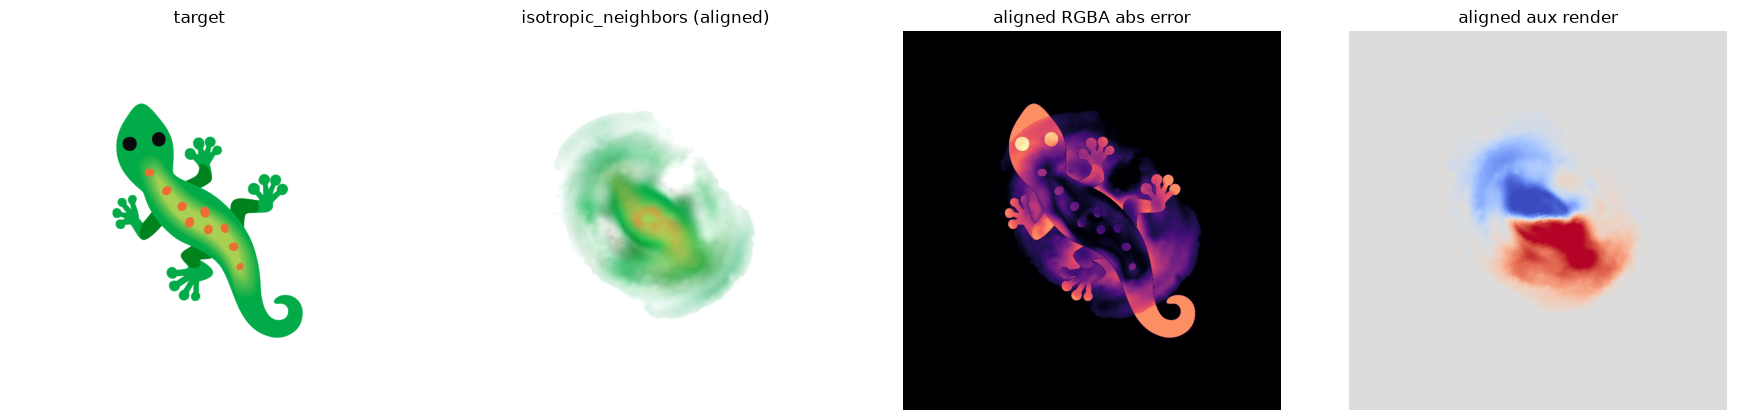

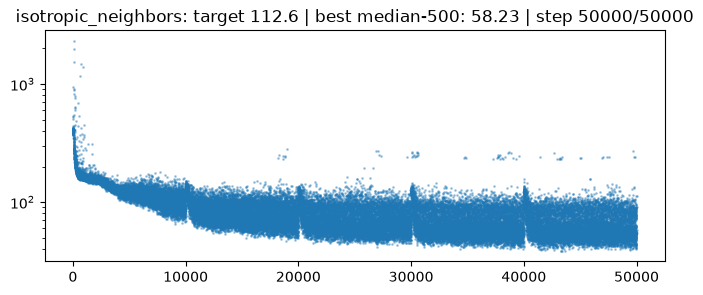

{'step': 50000, 'loss': 112.71842956542969, 'target': 112.64694213867188, 'overflow': 0.004018869716674089, 'diff': 0.003129440126940608, 'model_grad': 3691.056396484375, 'decoder_grad': 316.00079345703125, 'lr': 1.0070765380859375e-05, 'step_n': 95, 'pool_flushed': True, 'target_smoothed': 58.61667251586914}
visual alignment: {'loss_branch': 'mirror', 'phase_deg': 342.70091135045567, 'applied': 'rot+342.70+flip_y', 'spatial_mse': 0.025280684232711792}
checkpoint saved: notebook_runs/v3/isonca_lizard_lppn_isotropic_neighbors/latest.pt (step 50000)
checkpoint saved: notebook_runs/v3/isonca_lizard_lppn_isotropic_neighbors/step_00050000.pt (step 50000)
saved: notebook_runs/v3/isonca_lizard_lppn_isotropic_neighbors


In [8]:
#@title Train/resume the selected variant
def reset_dead_samples(model, x):
    if len(x) <= 1:
        return x
    dead = (x[1:, 3:4].sum(dim=(1, 2, 3), keepdim=True) < 1e-6).to(x.dtype)
    if dead.any():
        seed = make_seed(model, len(x) - 1, x.shape[-2], x.shape[-1])
        x[1:] = dead * seed + (1.0 - dead) * x[1:]
    return x

def train_variant(name):
    set_seed(SEED)
    model, decoder, loss_fn, renderer, grid_size = build_variant(name)
    with torch.no_grad():
        pool = make_seed(model, POOL_SIZE, *grid_size)
    optimizer = make_optimizer(model, decoder)
    scheduler = make_scheduler(optimizer)
    scaler = make_grad_scaler(device, PRECISION)
    start_step, pool, history = restore_training_checkpoint(
        name, model, decoder, optimizer, scheduler, scaler, pool
    )

    best_smoothed_target = min(
        (item['target_smoothed'] for item in history if 'target_smoothed' in item),
        default=float('inf'),
    )
    model.train()
    decoder.train()
    for step in range(start_step, TRAIN_STEPS + 1):
        pool_flushed = step > 0 and step % POOL_FLUSH_INTERVAL == 0
        if pool_flushed:
            # Restart the state curriculum while preserving Adam's moments
            # and the scheduler position. V2 reset all three together and
            # its loss spikes tracked the restarted cyclic-LR peaks.
            with torch.no_grad():
                pool = make_seed(model, POOL_SIZE, *grid_size)
            print(f'flushed pool at step {step}; optimizer and scheduler preserved')
        with torch.no_grad():
            batch_idx = np.random.choice(len(pool), BATCH_SIZE, replace=False)
            x = pool[batch_idx].clone()
            seed_rate = 1 if step < EARLY_SEED_STEPS else 6
            if step % seed_rate == 0:
                x[:1] = make_seed(model, 1, *grid_size)
            x = reset_dead_samples(model, x)

        step_n = np.random.randint(*STEP_RANGE)
        diff_loss = torch.zeros((), device=device, dtype=torch.float32)
        with autocast_context(device, PRECISION):
            for _ in range(step_n):
                previous_x = x
                x, _ = model(x)
                diff_loss = diff_loss + (x.float() - previous_x.float()).abs().mean()

        rendered_nhwc = render_channels(name, model, decoder, renderer, x)
        rendered = rendered_nhwc.permute(0, 3, 1, 2)
        x_up = F.interpolate(x.float(), size=rendered.shape[-2:], mode='bilinear', align_corners=False)
        target_loss, _, _ = loss_fn(
            {'generated_images': rendered, 'alpha': x_up[:, 3:4]},
            return_summary=False,
        )
        overflow_loss = (x.float() - x.float().clamp(-2.0, 2.0)).square().mean()
        mean_diff_loss = diff_loss / max(step_n, 1)
        loss = target_loss + OVERFLOW_WEIGHT * overflow_loss + DIFF_WEIGHT * mean_diff_loss
        if not torch.isfinite(loss):
            print(f'non-finite loss at step {step}; discarding batch and flushing pool')
            with torch.no_grad():
                pool = make_seed(model, POOL_SIZE, *grid_size)
            continue

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        model_grad = total_grad_norm(model)
        decoder_grad = total_grad_norm(decoder)
        if not torch.isfinite(model_grad) or not torch.isfinite(decoder_grad):
            # Discard the unstable batch and states. No optimizer step has
            # occurred, so its moments and scheduler can safely be retained.
            print(f'non-finite gradients at step {step}; discarding batch and flushing pool')
            optimizer.zero_grad(set_to_none=True)
            with torch.no_grad():
                pool = make_seed(model, POOL_SIZE, *grid_size)
            continue
        with torch.no_grad():
            normalize_model_grads(model)
            normalize_model_grads(decoder)
            optimizer_scheduler_step(optimizer, scheduler, scaler, PRECISION)
            pool[batch_idx] = x.detach().to(pool.dtype)

        row = {
            'step': step,
            'loss': float(loss.detach().cpu()),
            'target': float(target_loss.detach().cpu()),
            'overflow': float(overflow_loss.detach().cpu()),
            'diff': float(mean_diff_loss.detach().cpu()),
            'model_grad': float(model_grad.detach().cpu()),
            'decoder_grad': float(decoder_grad.detach().cpu()),
            'lr': float(optimizer.param_groups[0]['lr']),
            'step_n': int(step_n),
            'pool_flushed': pool_flushed,
        }
        history.append(row)

        if step % SUMMARY_INTERVAL == 0:
            if len(history) >= BEST_LOSS_WINDOW:
                recent_targets = [item['target'] for item in history[-BEST_LOSS_WINDOW:]]
                smoothed_target = float(np.median(recent_targets))
                row['target_smoothed'] = smoothed_target
                if smoothed_target < best_smoothed_target:
                    best_smoothed_target = smoothed_target
                    save_training_checkpoint(
                        name, step, model, decoder, optimizer, scheduler, scaler, pool, history,
                        filename='best.pt',
                    )
            clear_output(wait=True)
            aligned_rendered, alignment_info = align_render_to_target(
                loss_fn,
                rendered,
                x_up[:, 3:4],
                sample_index=0,
            )
            target_rgba = loss_fn.target_image[0, :4].detach().cpu().permute(1, 2, 0).numpy()
            image_rgba = aligned_rendered[0, :4].cpu().permute(1, 2, 0).numpy()
            aux_image = aligned_rendered[0, 4].cpu().numpy()
            fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
            axes[0].imshow(composite_rgba(target_rgba)); axes[0].set_title('target')
            axes[1].imshow(composite_rgba(image_rgba)); axes[1].set_title(name + ' (aligned)')
            axes[2].imshow(np.abs(composite_rgba(target_rgba) - composite_rgba(image_rgba)).mean(-1), cmap='magma'); axes[2].set_title('aligned RGBA abs error')
            axes[3].imshow(aux_image, cmap='coolwarm', vmin=-0.5, vmax=0.5); axes[3].set_title('aligned aux render')
            for axis in axes: axis.axis('off')
            plt.tight_layout(); plt.show()
            plt.figure(figsize=(8, 3))
            plt.plot([item['target'] for item in history], '.', ms=2, alpha=0.35)
            best_label = f' | best median-{BEST_LOSS_WINDOW}: {best_smoothed_target:.4g}' if np.isfinite(best_smoothed_target) else ''
            plt.yscale('log'); plt.title(f"{name}: target {row['target']:.4g}{best_label} | step {step}/{TRAIN_STEPS}")
            plt.show(); print(row); print('visual alignment:', alignment_info)

        if step > 0 and step % CHECKPOINT_INTERVAL == 0:
            save_training_checkpoint(name, step, model, decoder, optimizer, scheduler, scaler, pool, history)
            save_training_checkpoint(
                name, step, model, decoder, optimizer, scheduler, scaler, pool, history,
                filename=f'step_{step:08d}.pt',
            )

    out_dir = variant_output_dir(name)
    torch.save(model.state_dict(), out_dir / 'model.pth')
    torch.save(decoder.state_dict(), out_dir / 'decoder.pth')
    torch.save({
        'history': history, 'variant': name, 'train_steps': TRAIN_STEPS,
        'best_smoothed_target': best_smoothed_target, 'best_loss_window': BEST_LOSS_WINDOW,
    }, out_dir / 'run_meta.pth')
    print('saved:', out_dir)
    return {'name': name, 'model': model.eval(), 'decoder': decoder.eval(), 'loss_fn': loss_fn, 'renderer': renderer, 'grid_size': grid_size, 'history': history, 'path': out_dir}

trained_variant = train_variant(VARIANT_TO_RUN)

In [9]:
#@title Load every completed variant found on Drive
ALL_VARIANTS = ['interpolated_only', 'cartesian_coords', 'isotropic_neighbors', 'isotropic_neighbors_radial']

def load_completed_variant(name):
    model, decoder, loss_fn, renderer, grid_size = build_variant(name)
    candidate_dirs = [variant_output_dir(name, create=False)]
    if name == 'interpolated_only':
        candidate_dirs.append(Path('notebooks-executed/50k-run'))
    source = None
    out_dir = candidate_dirs[0]
    for candidate_dir in candidate_dirs:
        model_path = candidate_dir / 'model.pth'
        decoder_path = candidate_dir / 'decoder.pth'
        old_decoder_path = candidate_dir / 'siren.pth'
        latest_path = candidate_dir / 'latest.pt'
        if model_path.exists() and (decoder_path.exists() or old_decoder_path.exists()):
            model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
            selected_decoder_path = decoder_path if decoder_path.exists() else old_decoder_path
            decoder.load_state_dict(torch.load(selected_decoder_path, map_location=device, weights_only=True))
            source = selected_decoder_path
            out_dir = candidate_dir
            break
        if latest_path.exists():
            checkpoint = torch.load(latest_path, map_location=device, weights_only=False)
            model.load_state_dict(checkpoint['model'])
            decoder.load_state_dict(checkpoint.get('decoder', checkpoint.get('siren')))
            source = latest_path
            out_dir = candidate_dir
            break
    if source is None:
        return None
    print('loaded', name, 'from', source)
    return {'name': name, 'model': model.eval(), 'decoder': decoder.eval(), 'loss_fn': loss_fn, 'renderer': renderer, 'grid_size': grid_size, 'path': out_dir}

completed = {}
for completed_name in ALL_VARIANTS:
    item = load_completed_variant(completed_name)
    if item is not None:
        completed[completed_name] = item
print('Available for comparison:', list(completed))

interpolated_only | render: (768, 768) | NCA: (96, 96) | loss angles: 2414 | decoder params: 9,989
cartesian_coords | render: (768, 768) | NCA: (96, 96) | loss angles: 2414 | decoder params: 9,989
isotropic_neighbors | render: (768, 768) | NCA: (96, 96) | loss angles: 2414 | decoder params: 14,933
loaded isotropic_neighbors from notebook_runs/v3/isonca_lizard_lppn_isotropic_neighbors/decoder.pth
isotropic_neighbors_radial | render: (768, 768) | NCA: (96, 96) | loss angles: 2414 | decoder params: 14,981
Available for comparison: ['isotropic_neighbors']


In [10]:
#@title Trained decoder-only symmetry metrics on a non-symmetric field
def affine_rotate_nchw(x, angle_deg):
    angle = torch.tensor(angle_deg * torch.pi / 180.0, device=x.device, dtype=x.dtype)
    c, s = torch.cos(angle), torch.sin(angle)
    theta = torch.zeros(x.shape[0], 2, 3, device=x.device, dtype=x.dtype)
    theta[:, 0, 0] = c; theta[:, 0, 1] = -s
    theta[:, 1, 0] = s; theta[:, 1, 1] = c
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    return F.grid_sample(x, grid, mode='bilinear', padding_mode='zeros', align_corners=False)

def affine_rotate_nhwc(x, angle_deg):
    return affine_rotate_nchw(x.permute(0, 3, 1, 2), angle_deg).permute(0, 2, 3, 1)

set_seed(20260723)
probe = torch.randn(1, CHANNELS, 24, 24, device=device)
print('variant | kind | transform | mae | relative_l2')
with torch.no_grad():
    for name, item in completed.items():
        decoder = item['decoder']; renderer = item['renderer']
        base = decode_raw(name, decoder, renderer, probe)
        for label, transform_state, transform_image in D4_TRANSFORMS:
            actual = decode_raw(name, decoder, renderer, transform_state(probe))
            expected = transform_image(base)
            print(f'{name} | exact_D4 | {label} | {(actual-expected).abs().mean().item():.3e} | {rel_l2(actual, expected).mean().item():.3e}')
        for angle in [30.0, 45.0, 60.0]:
            actual = decode_raw(name, decoder, renderer, affine_rotate_nchw(probe, angle))
            expected = affine_rotate_nhwc(base, angle)
            margin = SCALE_FACTOR * 2
            actual_crop = actual[:, margin:-margin, margin:-margin]
            expected_crop = expected[:, margin:-margin, margin:-margin]
            print(f'{name} | interpolated | rot{angle:g} | {(actual_crop-expected_crop).abs().mean().item():.3e} | {rel_l2(actual_crop, expected_crop).mean().item():.3e}')
        if name.startswith('isotropic_neighbors'):
            permuted = decode_raw(name, decoder, renderer, probe, neighbor_permutation=[2, 0, 3, 1])
            print(f'{name} | set_order | permutation | {(permuted-base).abs().mean().item():.3e} | {rel_l2(permuted, base).mean().item():.3e}')

variant | kind | transform | mae | relative_l2
isotropic_neighbors | exact_D4 | rot90 | 2.846e-08 | 1.929e-07
isotropic_neighbors | exact_D4 | rot180 | 2.908e-08 | 1.970e-07
isotropic_neighbors | exact_D4 | rot270 | 2.850e-08 | 1.930e-07
isotropic_neighbors | exact_D4 | flip_x | 2.671e-08 | 1.822e-07
isotropic_neighbors | exact_D4 | flip_y | 2.904e-08 | 1.965e-07
isotropic_neighbors | interpolated | rot30 | 6.364e-02 | 4.846e-01
isotropic_neighbors | interpolated | rot45 | 6.142e-02 | 4.721e-01
isotropic_neighbors | interpolated | rot60 | 6.215e-02 | 4.664e-01
isotropic_neighbors | set_order | permutation | 1.734e-08 | 1.233e-07


In [11]:
#@title End-to-end equivariance with paired stochastic update masks
def transform_pair(label, tensor, image=False):
    if label.startswith('rot'):
        k = int(label.removeprefix('rot')) // 90
        return torch.rot90(tensor, k, dims=(-3, -2) if image else (-2, -1))
    if label == 'flip_x':
        return torch.flip(tensor, dims=(-2,) if image else (-1,))
    if label == 'flip_y':
        return torch.flip(tensor, dims=(-3,) if image else (-2,))
    raise ValueError(label)

@torch.no_grad()
def rollout_with_masks(model, x, masks):
    for update_mask in masks:
        x, _ = model(x, update_mask=update_mask)
    return x

pathwise_results = {}
print('variant | transform | state_rel_l2 | render_rel_l2 | render_mae')
for variant_index, (name, item) in enumerate(completed.items()):
    model, decoder, renderer = item['model'], item['decoder'], item['renderer']
    h, w = item['grid_size']
    mask_generator = torch.Generator(device=device).manual_seed(9100 + variant_index)
    masks = (torch.rand(EVAL_STEPS, 1, 1, h, w, device=device, generator=mask_generator) < UPDATE_PROB).to(PRECISION)
    seed = make_seed(model, 1, h, w)
    base_state = rollout_with_masks(model, seed, masks)
    with torch.no_grad():
        base_image = render_channels(name, model, decoder, renderer, base_state)
    base_alpha = F.interpolate(base_state.float(), size=base_image.shape[1:3], mode='bilinear', align_corners=False)[:, 3:4]
    pathwise_results[name] = {'base': base_image.detach().cpu(), 'nca_alpha': base_alpha.detach().cpu()}
    for label in ['rot90', 'rot180', 'rot270', 'flip_x', 'flip_y']:
        transformed_seed = transform_pair(label, seed)
        transformed_masks = transform_pair(label, masks)
        actual_state = rollout_with_masks(model, transformed_seed, transformed_masks)
        with torch.no_grad():
            actual_image = render_channels(name, model, decoder, renderer, actual_state)
        expected_state = transform_pair(label, base_state)
        expected_image = transform_pair(label, base_image, image=True)
        pathwise_results[name][label] = {
            'actual': actual_image.detach().cpu(),
            'expected': expected_image.detach().cpu(),
            'error': (actual_image - expected_image).abs().detach().cpu(),
        }
        print(f'{name} | {label} | {rel_l2(actual_state, expected_state).mean().item():.3e} | {rel_l2(actual_image[..., :4], expected_image[..., :4]).mean().item():.3e} | {(actual_image[..., :4]-expected_image[..., :4]).abs().mean().item():.3e}')

variant | transform | state_rel_l2 | render_rel_l2 | render_mae
isotropic_neighbors | rot90 | 3.148e-04 | 1.688e-03 | 2.463e-05
isotropic_neighbors | rot180 | 8.790e-04 | 2.759e-03 | 4.325e-05
isotropic_neighbors | rot270 | 1.370e-03 | 2.144e-03 | 2.974e-05
isotropic_neighbors | flip_x | 2.647e-04 | 1.182e-03 | 2.175e-05
isotropic_neighbors | flip_y | 1.355e-03 | 1.637e-03 | 2.784e-05


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.036629822..1.0256127].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.036646258..1.0256288].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.036629822..1.0256127].


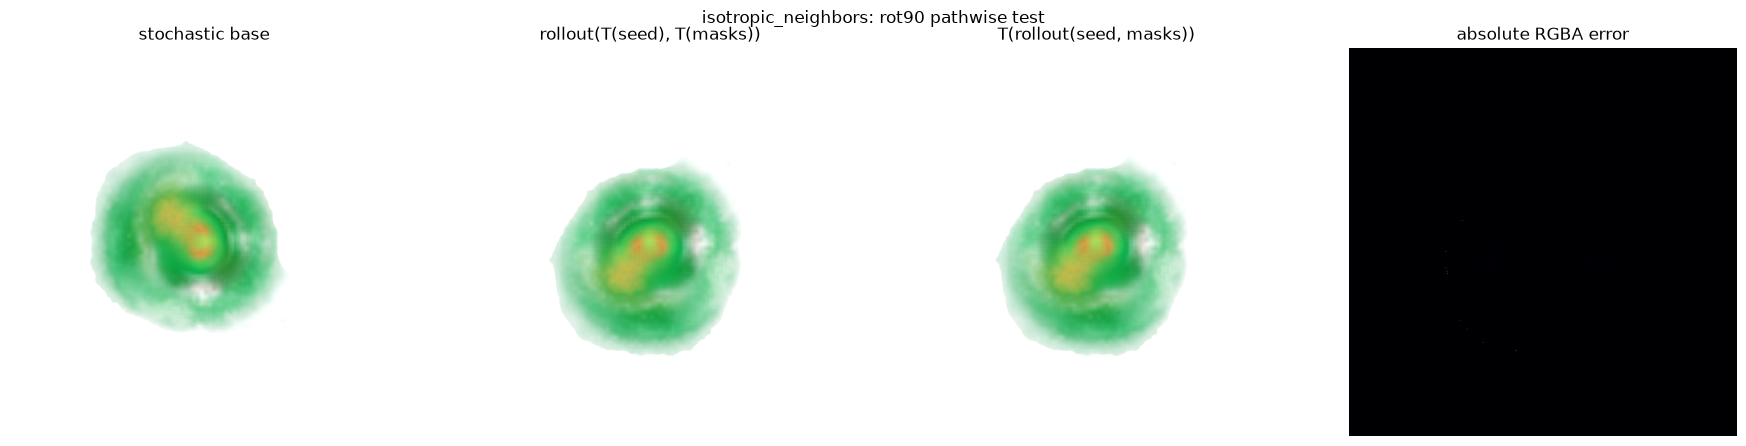

variant | invariant_target_loss | edge_energy | boundary/interior gradient
isotropic_neighbors | 135.66 | 0.0012679 | 0.88277


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.026583303..1.0196843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.025871474..1.0218011].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.025634568..1.0226532].


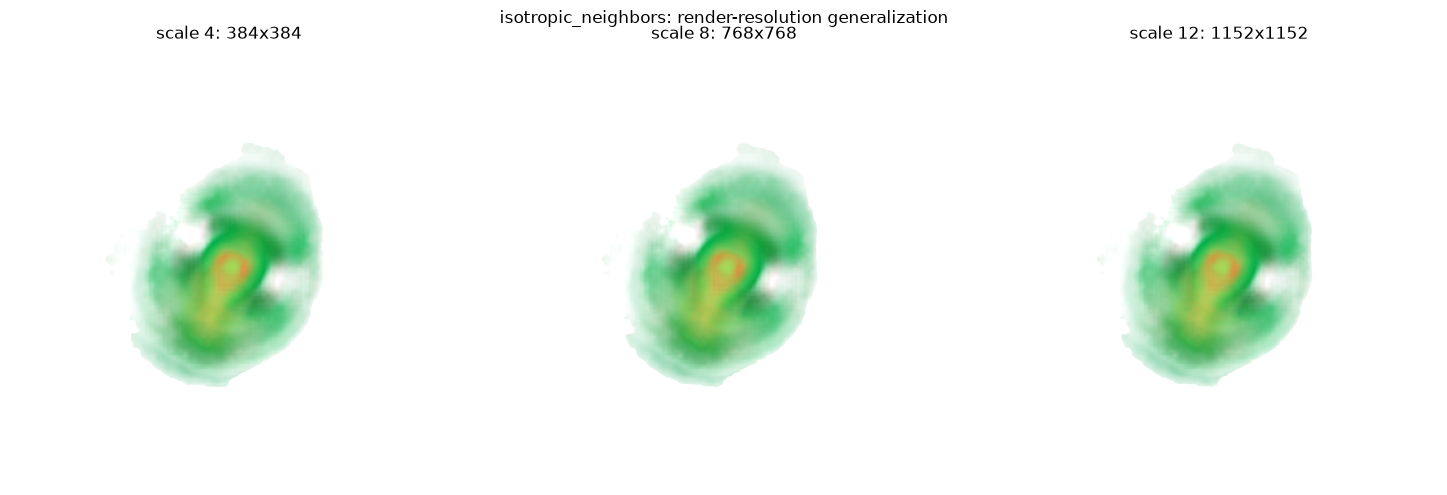

In [12]:
#@title Comparison visuals and simple detail/boundary metrics
def edge_energy(image):
    rgb = image[..., :3] * image[..., 3:4].clamp(0.0, 1.0)
    dx = (rgb[:, :, 1:] - rgb[:, :, :-1]).abs().mean()
    dy = (rgb[:, 1:] - rgb[:, :-1]).abs().mean()
    return (dx + dy).item()

def primitive_boundary_ratio(image, scale_factor=SCALE_FACTOR):
    rgb = image[..., :3] * image[..., 3:4].clamp(0.0, 1.0)
    dx = (rgb[:, :, 1:] - rgb[:, :, :-1]).abs().mean(dim=-1)
    dy = (rgb[:, 1:] - rgb[:, :-1]).abs().mean(dim=-1)
    x_boundary = torch.arange(dx.shape[-1], device=dx.device) % scale_factor == scale_factor - 1
    y_boundary = torch.arange(dy.shape[-2], device=dy.device) % scale_factor == scale_factor - 1
    boundary = torch.cat([dx[..., x_boundary].reshape(-1), dy[:, y_boundary].reshape(-1)]).mean()
    interior = torch.cat([dx[..., ~x_boundary].reshape(-1), dy[:, ~y_boundary].reshape(-1)]).mean()
    return (boundary / (interior + 1e-8)).item()

for name, result in pathwise_results.items():
    base = result['base'][0].numpy()
    transformed = result['rot90']['actual'][0].numpy()
    expected = result['rot90']['expected'][0].numpy()
    error = result['rot90']['error'][0, ..., :4].mean(-1).numpy()
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    axes[0].imshow(composite_rgba(base[..., :4])); axes[0].set_title('stochastic base')
    axes[1].imshow(composite_rgba(transformed[..., :4])); axes[1].set_title('rollout(T(seed), T(masks))')
    axes[2].imshow(composite_rgba(expected[..., :4])); axes[2].set_title('T(rollout(seed, masks))')
    axes[3].imshow(error, cmap='magma'); axes[3].set_title('absolute RGBA error')
    for axis in axes: axis.axis('off')
    fig.suptitle(name + ': rot90 pathwise test'); plt.tight_layout(); plt.show()

print('variant | invariant_target_loss | edge_energy | boundary/interior gradient')
for name, item in completed.items():
    image = pathwise_results[name]['base'].to(device)
    state_alpha = pathwise_results[name]['nca_alpha'].to(device)
    target_loss, _, _ = item['loss_fn'](
        {'generated_images': image.permute(0, 3, 1, 2), 'alpha': state_alpha},
        return_summary=False,
    )
    print(f'{name} | {target_loss.item():.5g} | {edge_energy(image):.5g} | {primitive_boundary_ratio(image):.5g}')

# Resolution-generalization spot check from the same final NCA state.
for name, item in completed.items():
    model = item['model']; h, w = item['grid_size']
    generator = torch.Generator(device=device).manual_seed(12000)
    masks = (torch.rand(EVAL_STEPS, 1, 1, h, w, device=device, generator=generator) < UPDATE_PROB).to(PRECISION)
    with torch.no_grad():
        state = rollout_with_masks(model, make_seed(model, 1, h, w), masks)
        images = [render_channels(name, model, item['decoder'], item['renderer'], state, scale_factor=scale).cpu()[0].numpy() for scale in [4, 8, 12]]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for axis, scale, image in zip(axes, [4, 8, 12], images):
        axis.imshow(composite_rgba(image[..., :4])); axis.set_title(f'scale {scale}: {image.shape[0]}x{image.shape[1]}'); axis.axis('off')
    fig.suptitle(name + ': render-resolution generalization'); plt.tight_layout(); plt.show()

## GPU export

After training, run the cell below. It creates one `.tar.gz` containing:

- `model.pth`: trained IsoNCA weights.
- `decoder.pth`: trained LPPN decoder weights.
- `run_meta.pth`: loss history and run metadata.
- `latest.pt`: final resumable state, including the optimizer, scheduler, and training pool.
- `best.pt`: resumable state with the best rolling-median target loss.

Numbered `step_XXXXXXXX.pt` checkpoints remain in the run directory but are excluded from the download archive to keep it manageable. Also download the executed notebook separately to preserve its plots and printed metrics.

In [13]:
#@title Package trained artifacts for download
import tarfile

artifact_dir = variant_output_dir(VARIANT_TO_RUN, create=False)
artifact_names = ['model.pth', 'decoder.pth', 'run_meta.pth', 'latest.pt', 'best.pt']
missing_artifacts = [name for name in artifact_names if not (artifact_dir / name).exists()]
if missing_artifacts:
    raise FileNotFoundError(
        f'Missing {missing_artifacts} in {artifact_dir}. Finish training before packaging.'
    )
archive_path = artifact_dir.parent / f'{artifact_dir.name}_artifacts.tar.gz'
with tarfile.open(archive_path, 'w:gz') as archive:
    for name in artifact_names:
        archive.add(artifact_dir / name, arcname=name)
print('Download this archive:', archive_path)
print('Also save this executed notebook from JupyterLab to retain plots and metrics.')

Download this archive: notebook_runs/v3/isonca_lizard_lppn_isotropic_neighbors_artifacts.tar.gz
Also save this executed notebook from JupyterLab to retain plots and metrics.
